Plots for epednn_multieq_profilesloop.py runs

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [3]:
# Inputs
out_dir = 'multiequil_kbmavg'

In [4]:
success = np.load(f'{out_dir}/success.npy', allow_pickle=True)
failed = np.load(f'{out_dir}/failed.npy', allow_pickle=True)

Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified


In [5]:
def read_pfile(path):
    data = {}
    key = ''
    with open(path) as f:
        for line in f:
            if '3 N Z A' in line:
                break
            if line.startswith('201'):
                key = line.split()[2]
                data[key] = np.array([])
                data[f'{key}_psi'] = np.array([])
            else:
                psi, dat, _ = line.split()
                psi = float(psi)
                dat = float(dat)
                data[key] = np.append(data[key], dat)
                data[f'{key}_psi'] = np.append(data[f'{key}_psi'], psi)
    return data

In [7]:
print(success[0].keys())

dict_keys(['mhd_fp', 'kprof_fp', 'ped_h', 'ped_wid', 'p_gfile'])


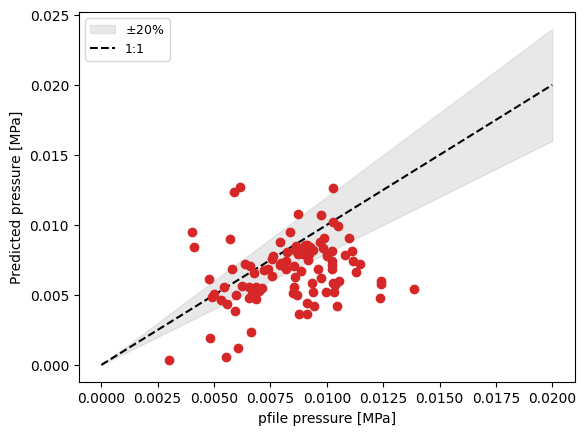

In [10]:
# For the successful equilibria, plot the predicted pressure vs. geqdsk pressure at psiN=1-delta and psiN=0.85
fig, ax = plt.subplots()
for out_dict in success:
    pf = read_pfile(out_dict['kprof_fp'])

    # Store pfile information
    T_e_pfile = pf['te(KeV)'] # T_e values (keV) evaluated at psi_Te_eval
    psi_Te_eval_pfile = pf['te(KeV)_psi'] # psi_N values at which T_e is evaluated

    n_e_pfile = pf['ne(10^20/m^3)'] * 1e20 # n_e values (10^20/m^3 -> m^-3) evaluated at psi_ne_eval
    psi_ne_eval = pf['ne(10^20/m^3)_psi'] # psi_N values at which n_e is evaluated

    T_i_pfile = pf['ti(KeV)'] # T_e values (keV) evaluated at psi_Te_eval
    psi_Ti_eval_pfile = pf['ti(KeV)_psi'] # psi_N values at which T_e is evaluated

    n_i_pfile = pf['ni(10^20/m^3)'] * 1e20 # n_e values (10^20/m^3 -> m^-3) evaluated at psi_ne_eval
    psi_ni_eval = pf['ni(10^20/m^3)_psi'] # psi_N values at which n_e is evaluated

    # "Correct" pressure: pfile total pressure at ped [Pa]
    T_e_ped = np.interp(1-out_dict['ped_wid'], psi_Te_eval_pfile, T_e_pfile) * 1e3  # keV -> eV
    n_e_ped = np.interp(1-out_dict['ped_wid'], psi_ne_eval, n_e_pfile)
    T_i_ped = np.interp(1-out_dict['ped_wid'], psi_Ti_eval_pfile, T_i_pfile) * 1e3  # keV -> eV
    n_i_ped = np.interp(1-out_dict['ped_wid'], psi_ni_eval, n_i_pfile)
    p_ped_h = (n_e_ped * T_e_ped + n_i_ped * T_i_ped) * 1.602176634e-19
    # ax.plot(out_dict['ped_h'], p_ped_h / 1e6,'o',color='tab:blue')
    ax.plot(out_dict['ped_h'], out_dict['p_gfile'] / 1e6,'o',color='tab:red')

x_line = np.linspace(0, 0.02, 200)
pm = 20
ax.fill_between(
    x_line, (1-(pm/100)) * x_line, (1+(pm/100)) * x_line,
    color='0.75', alpha=0.35, label=f'$\pm {pm}\\%$',
    zorder=0,
)
ax.plot(x_line, x_line, 'k--', label='1:1', zorder=1)
ax.set_xlabel('pfile pressure [MPa]')
ax.set_ylabel('Predicted pressure [MPa]')
ax.legend(loc='upper left', fontsize=9)

In [7]:
len(success)

94